In [7]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# 1. Cargar datos
data_dir = 'D:/2do_cuatri_erasmus/intro_computer_vision_and_quality_control/project/data/DATA_Maguire_20180517_ALL/final'
batch_size = 32
img_height = 224
img_width = 224

train_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="training", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size, follow_links=False)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="validation", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size, follow_links=False)

class_names = train_dataset.class_names

# 2. Optimización en memoria
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 3. Calcular pesos
total_cracked = 8484
total_non_cracked = 47608
total_images = total_cracked + total_non_cracked

class_weight = {
    0: (1 / total_cracked) * (total_images / 2.0), 
    1: (1 / total_non_cracked) * (total_images / 2.0)
}
print("\nDatos cargados y pesos calculados.")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 56092 files belonging to 2 classes.
Using 44874 files for training.
Found 56092 files belonging to 2 classes.
Using 11218 files for validation.

Datos cargados y pesos calculados.


In [8]:
# 1. Arquitectura
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2), 
    tf.keras.layers.RandomContrast(0.2)  
], name="data_augmentation")

base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

# 2. Entrenar
print("Arrancando entrenamiento de Fase 2 (10 épocas)...")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10, class_weight=class_weight)

# 3. ¡GUARDAR EL MODELO! (El salvavidas)
model.save('modelo_fase2_resnet.h5')
print("\n¡MODELO GUARDADO EXITOSAMENTE en el disco duro!")

Arrancando entrenamiento de Fase 2 (10 épocas)...
Epoch 1/10
1403/1403 [==============================] - 855s 336ms/step - loss: 0.4816 - accuracy: 0.7973 - recall: 0.8127 - val_loss: 0.3219 - val_accuracy: 0.8888 - val_recall: 0.9324
Epoch 2/10
1403/1403 [==============================] - 528s 376ms/step - loss: 0.4476 - accuracy: 0.8236 - recall: 0.8407 - val_loss: 0.2980 - val_accuracy: 0.8974 - val_recall: 0.9450
Epoch 3/10
1403/1403 [==============================] - 511s 364ms/step - loss: 0.4427 - accuracy: 0.8260 - recall: 0.8426 - val_loss: 0.2944 - val_accuracy: 0.9013 - val_recall: 0.9468
Epoch 4/10
1403/1403 [==============================] - 514s 366ms/step - loss: 0.4358 - accuracy: 0.8329 - recall: 0.8494 - val_loss: 0.2745 - val_accuracy: 0.9093 - val_recall: 0.9609
Epoch 5/10
1403/1403 [==============================] - 514s 366ms/step - loss: 0.4313 - accuracy: 0.8317 - recall: 0.8483 - val_loss: 0.2998 - val_accuracy: 0.8953 - val_recall: 0.9368
Epoch 6/10
1403/1403

Extrayendo etiquetas y calculando predicciones...

351/351 [==============================] - 36s 101ms/step
=== RESULTADOS CON UMBRAL ESTÁNDAR (0.5) ===
              precision    recall  f1-score   support

     Cracked       0.74      0.63      0.68      1708
 Non_Cracked       0.94      0.96      0.95      9510

    accuracy                           0.91     11218
   macro avg       0.84      0.80      0.81     11218
weighted avg       0.91      0.91      0.91     11218


=== RESULTADOS CON UMBRAL SENSIBLE (0.3) ===
              precision    recall  f1-score   support

     Cracked       0.86      0.52      0.65      1708
 Non_Cracked       0.92      0.98      0.95      9510

    accuracy                           0.91     11218
   macro avg       0.89      0.75      0.80     11218
weighted avg       0.91      0.91      0.90     11218



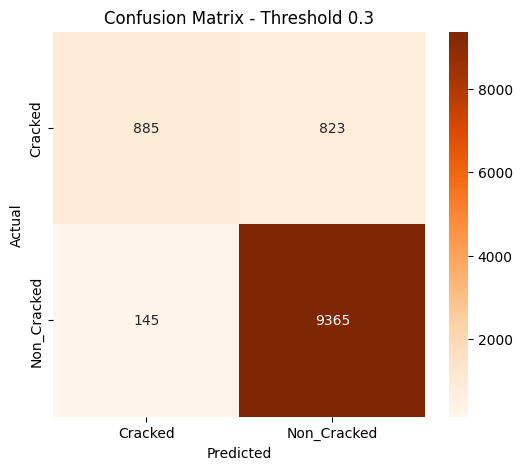

In [9]:
print("Extrayendo etiquetas y calculando predicciones...\n")
val_labels = np.concatenate([y for x, y in validation_dataset], axis=0)
val_preds_probs = model.predict(validation_dataset)

# --- UMBRAL ESTÁNDAR (0.5) ---
val_preds_50 = (val_preds_probs > 0.5).astype(int).flatten()
print("=== RESULTADOS CON UMBRAL ESTÁNDAR (0.5) ===")
print(classification_report(val_labels, val_preds_50, target_names=class_names))

# --- OPCIÓN A: UMBRAL SENSIBLE (0.3) ---
val_preds_30 = (val_preds_probs > 0.3).astype(int).flatten()
print("\n=== RESULTADOS CON UMBRAL SENSIBLE (0.3) ===")
print(classification_report(val_labels, val_preds_30, target_names=class_names))

# Pintamos la Matriz de la Opción A
cm_30 = confusion_matrix(val_labels, val_preds_30)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_30, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Threshold 0.3')
plt.show()

In [ ]:
print("Iniciando Fine-Tuning (Descongelando ResNet50)...")

# 1. Descongelamos el modelo base
base_model.trainable = True

# 2. Re-compilamos el modelo. CRÍTICO: Usar un learning_rate minúsculo (1e-5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

# 3. Entrenamos 5 épocas más sobre lo que ya sabe
history_fine = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, class_weight=class_weight)

# 4. Guardamos esta versión final superior
model.save('modelo_fase2_finetuned.h5')
print("\n¡Modelo Fine-Tuned guardado como 'modelo_fase2_finetuned.h5'!")

# 5. Evaluar la mejora final (Umbral 0.5)
val_preds_probs_fine = model.predict(validation_dataset)
val_preds_fine = (val_preds_probs_fine > 0.5).astype(int).flatten()

print("\n=== RESULTADOS TRAS FINE-TUNING ===")
print(classification_report(val_labels, val_preds_fine, target_names=class_names))